In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [18]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [19]:
missing = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].isna().sum()
print('Age:', missing['Age'])
print('Annual Income:', missing['Annual Income (k$)'])
print('Spending Score:', missing['Spending Score (1-100)'])

Age: 0
Annual Income: 0
Spending Score: 0


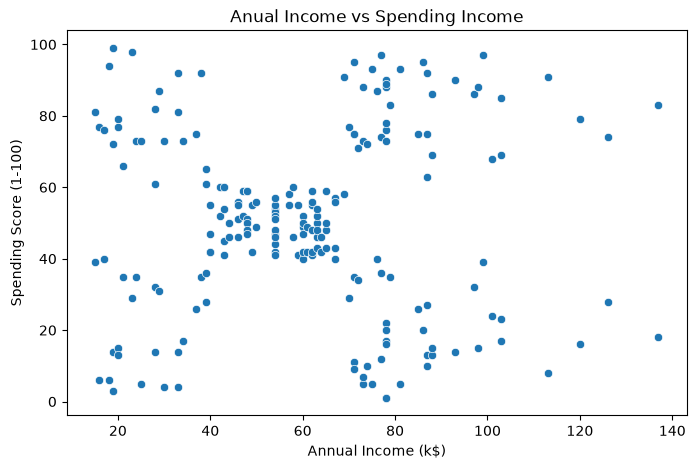

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')
plt.title('Anual Income vs Spending Income')
plt.show()

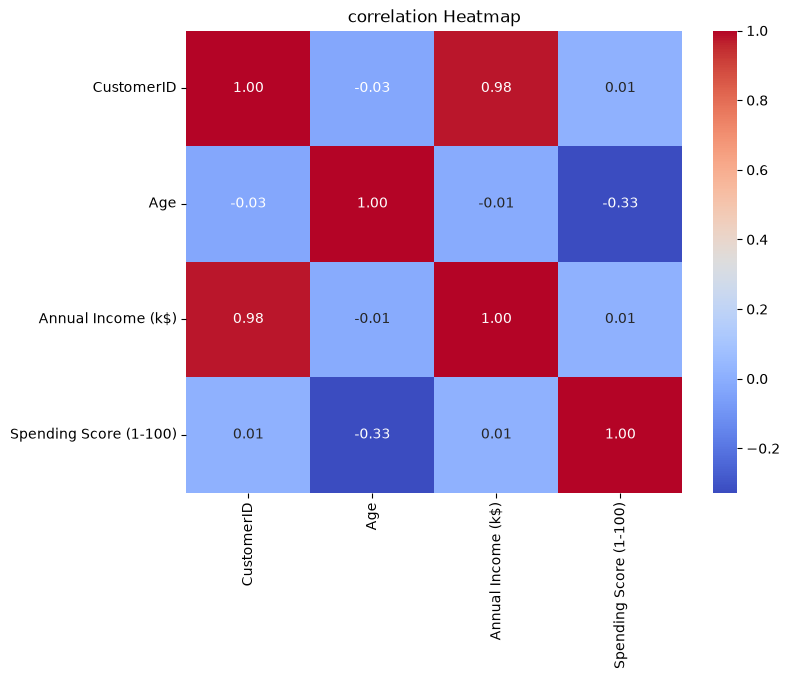

Most strongly correlated features: CustomerID and Annual Income (k$)
Correlation: 0.98


In [21]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('correlation Heatmap')
plt.show()

corr_matrix = corr.copy()
for column in corr_matrix.columns:
    corr_matrix.loc[column, column] = 0

corr_pair = corr_matrix.abs().stack().idxmax()
corr_value = corr.loc[corr_pair[0], corr_pair[1]]

print('Most strongly correlated features:', corr_pair[0], 'and', corr_pair[1])
print('Correlation:', round(corr_value, 2))

In [22]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2
5,6,Female,22,17,76,2
6,7,Female,35,18,6,2
7,8,Female,23,18,94,2
8,9,Male,64,19,3,2
9,10,Female,30,19,72,2


In [23]:
df['Cluster'].value_counts().sort_index()

Cluster
0     38
1     39
2    123
Name: count, dtype: int64